# Import Required Libraries
Import the necessary libraries, including pandas for data manipulation and matplotlib for plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data from CSV File
Use pandas to read the bh.csv file into a DataFrame.

In [2]:
df = pd.read_csv('bh.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (42, 2)


# Explore the Dataset
Display the first few rows of the dataset and check the data types to understand the structure.

In [3]:
print("First few rows:")
print(df.head())
print("\nData info:")
print(df.info())

First few rows:
         vbh        bh
0 -90.758976  0.005190
1 -79.224672  0.006920
2 -75.941184  0.003460
3 -74.594112  0.002595
4 -67.606176  0.016435

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vbh     42 non-null     float64
 1   bh      42 non-null     float64
dtypes: float64(2)
memory usage: 804.0 bytes
None


# Bootstrap Analysis
Generate bootstrap samples and fit each to bh = Ah/(1+exp(-(vbh+v05h)/zh)) to estimate parameter uncertainties.

In [4]:
from scipy.optimize import curve_fit
import numpy as np

# Define the fitting function
def bh_function(vbh, Ah, v05h, zh):
    return Ah / (1 + np.exp(-(vbh + v05h) / zh))

# Initial guesses for parameters
initial_guess = [1, 35, 10]

# Bootstrap parameters
n_bootstrap = 4000
n_samples = len(df)

# Arrays to store bootstrap results
Ah_bootstrap = []
v05h_bootstrap = []
zh_bootstrap = []

# Perform bootstrap resampling
np.random.seed(42)  # For reproducibility

for i in range(n_bootstrap):
    # Resample with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    vbh_resample = df['vbh'].iloc[indices].values
    bh_resample = df['bh'].iloc[indices].values
    
    try:
        # Fit the resampled data
        popt_boot, _ = curve_fit(bh_function, vbh_resample, bh_resample, p0=initial_guess)
        Ah_bootstrap.append(popt_boot[0])
        v05h_bootstrap.append(popt_boot[1])
        zh_bootstrap.append(popt_boot[2])
    except:
        # Skip if fit fails
        continue

# Convert to numpy arrays
Ah_bootstrap = np.array(Ah_bootstrap)
v05h_bootstrap = np.array(v05h_bootstrap)
zh_bootstrap = np.array(zh_bootstrap)

print(f"Bootstrap Analysis Results (n={len(Ah_bootstrap)} successful fits):")
print(f"\nParameter Ah:")
print(f"  Mean = {np.mean(Ah_bootstrap):.6f}")
print(f"  Std  = {np.std(Ah_bootstrap):.6f}")
print(f"\nParameter v05h:")
print(f"  Mean = {np.mean(v05h_bootstrap):.6f}")
print(f"  Std  = {np.std(v05h_bootstrap):.6f}")
print(f"\nParameter zh:")
print(f"  Mean = {np.mean(zh_bootstrap):.6f}")
print(f"  Std  = {np.std(zh_bootstrap):.6f}")

Bootstrap Analysis Results (n=3999 successful fits):

Parameter Ah:
  Mean = 0.962329
  Std  = 0.103987

Parameter v05h:
  Mean = 34.889744
  Std  = 5.764508

Parameter zh:
  Mean = 11.852037
  Std  = 4.735941


# Plot Data with Bootstrap Mean Fit and Confidence Limits
Show the mean fit from bootstrap analysis with confidence intervals.

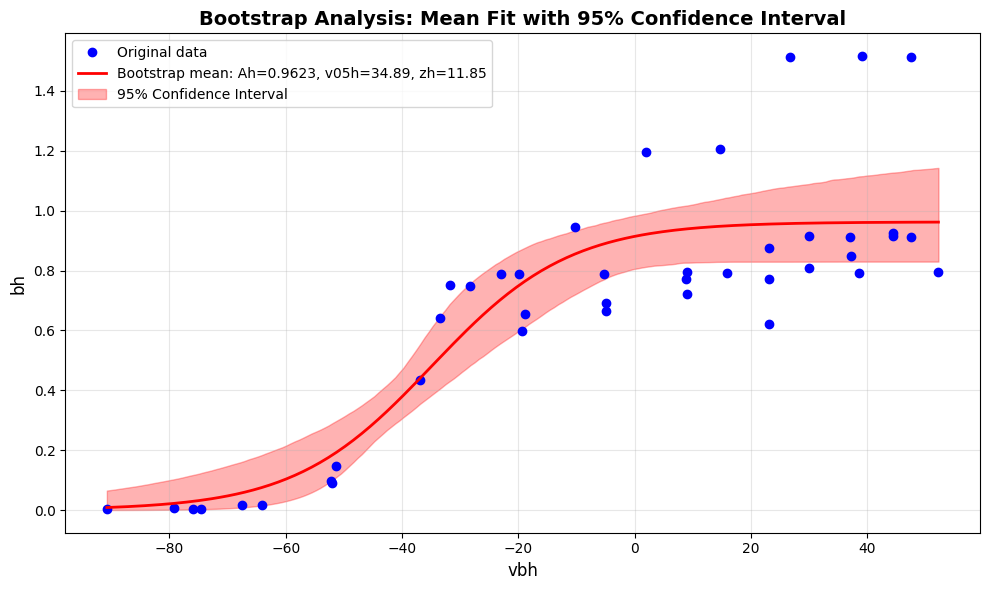

In [5]:
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(df['vbh'], df['bh'], 'o', label='Original data', markersize=6, color='blue')

# Generate smooth curve for mean bootstrap fit
vbh_smooth = np.linspace(df['vbh'].min(), df['vbh'].max(), 200)
Ah_mean = np.mean(Ah_bootstrap)
v05h_mean = np.mean(v05h_bootstrap)
zh_mean = np.mean(zh_bootstrap)
bh_mean = bh_function(vbh_smooth, Ah_mean, v05h_mean, zh_mean)

# Calculate confidence limits (95% CI using 2.5th and 97.5th percentiles)
bh_curves = np.array([bh_function(vbh_smooth, Ah_bootstrap[i], v05h_bootstrap[i], zh_bootstrap[i]) 
                      for i in range(len(Ah_bootstrap))])
bh_lower = np.percentile(bh_curves, 2.5, axis=0)
bh_upper = np.percentile(bh_curves, 97.5, axis=0)

# Plot mean fit and confidence interval
plt.plot(vbh_smooth, bh_mean, '-', linewidth=2, color='red', 
         label=f'Bootstrap mean: Ah={Ah_mean:.4f}, v05h={v05h_mean:.2f}, zh={zh_mean:.2f}')
plt.fill_between(vbh_smooth, bh_lower, bh_upper, alpha=0.3, color='red', 
                 label='95% Confidence Interval')

plt.xlabel('vbh', fontsize=12)
plt.ylabel('bh', fontsize=12)
plt.title('Bootstrap Analysis: Mean Fit with 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histograms of Bootstrap Parameters
Distribution of Ah, v05h, and zh from bootstrap resampling.

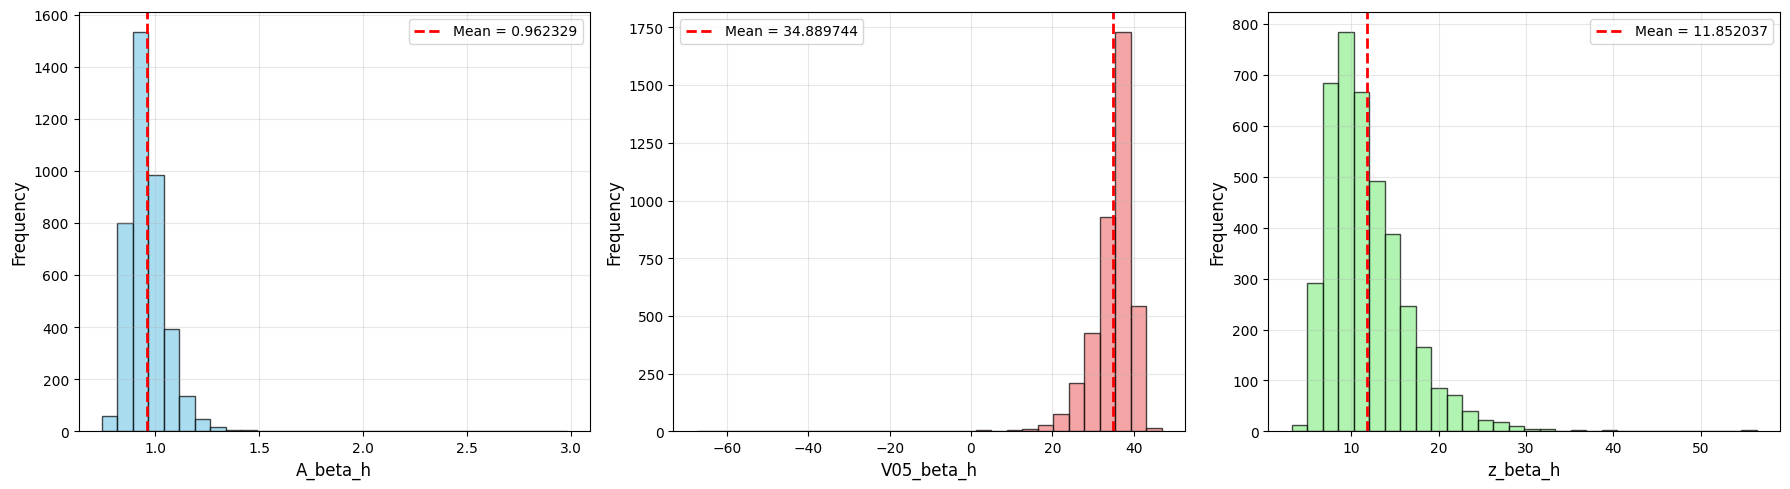

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of Ah
axes[0].hist(Ah_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(np.mean(Ah_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(Ah_bootstrap):.6f}')
axes[0].set_xlabel('A_beta_h', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of v05h
axes[1].hist(v05h_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(np.mean(v05h_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(v05h_bootstrap):.6f}')
axes[1].set_xlabel('V05_beta_h', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Histogram of zh
axes[2].hist(zh_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].axvline(np.mean(zh_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(zh_bootstrap):.6f}')
axes[2].set_xlabel('z_beta_h', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parameter Correlations
Scatter plots showing the relationships between fitted parameters from bootstrap samples.

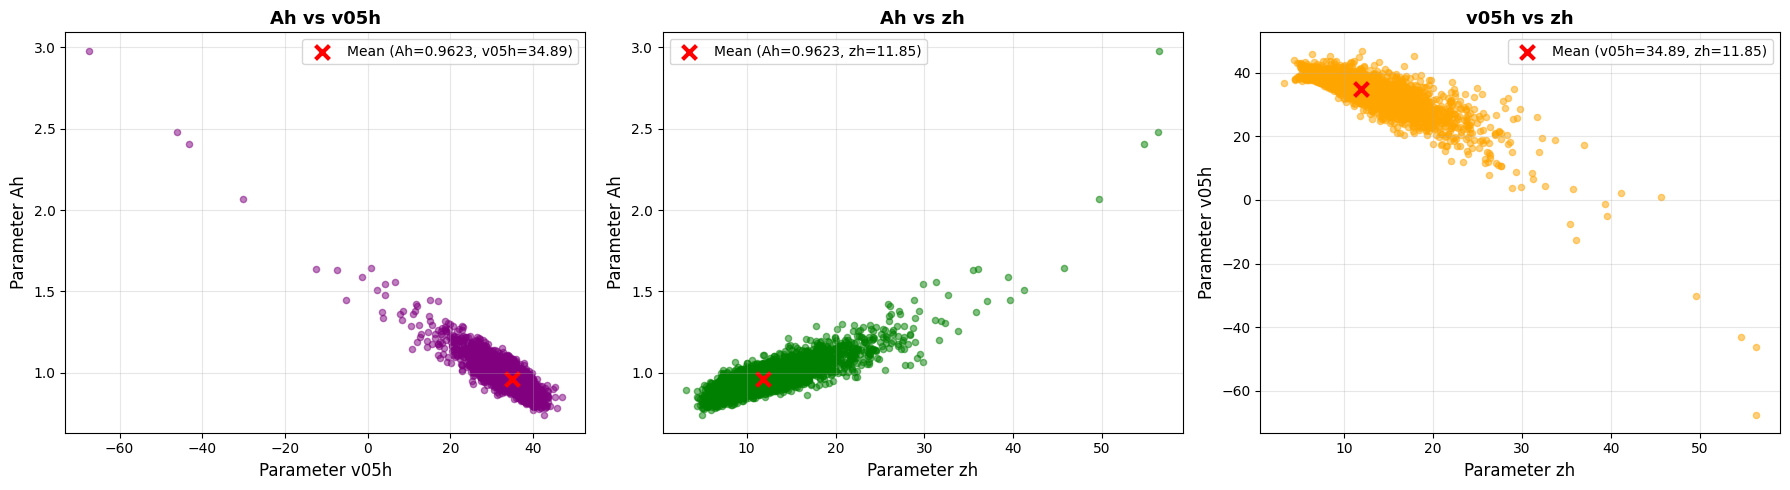


Correlation coefficients:
  Ah vs v05h: -0.9000
  Ah vs zh:   0.8496
  v05h vs zh: -0.8601


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate mean parameters
Ah_mean = np.mean(Ah_bootstrap)
v05h_mean = np.mean(v05h_bootstrap)
zh_mean = np.mean(zh_bootstrap)

# Scatter plot of Ah vs v05h
axes[0].scatter(v05h_bootstrap, Ah_bootstrap, alpha=0.5, s=20, color='purple')
axes[0].scatter(v05h_mean, Ah_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (Ah={Ah_mean:.4f}, v05h={v05h_mean:.2f})')
axes[0].set_xlabel('Parameter v05h', fontsize=12)
axes[0].set_ylabel('Parameter Ah', fontsize=12)
axes[0].set_title('Ah vs v05h', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Scatter plot of Ah vs zh
axes[1].scatter(zh_bootstrap, Ah_bootstrap, alpha=0.5, s=20, color='green')
axes[1].scatter(zh_mean, Ah_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (Ah={Ah_mean:.4f}, zh={zh_mean:.2f})')
axes[1].set_xlabel('Parameter zh', fontsize=12)
axes[1].set_ylabel('Parameter Ah', fontsize=12)
axes[1].set_title('Ah vs zh', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Scatter plot of v05h vs zh
axes[2].scatter(zh_bootstrap, v05h_bootstrap, alpha=0.5, s=20, color='orange')
axes[2].scatter(zh_mean, v05h_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (v05h={v05h_mean:.2f}, zh={zh_mean:.2f})')
axes[2].set_xlabel('Parameter zh', fontsize=12)
axes[2].set_ylabel('Parameter v05h', fontsize=12)
axes[2].set_title('v05h vs zh', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation coefficients
corr_Ah_v05h = np.corrcoef(Ah_bootstrap, v05h_bootstrap)[0, 1]
corr_Ah_zh = np.corrcoef(Ah_bootstrap, zh_bootstrap)[0, 1]
corr_v05h_zh = np.corrcoef(v05h_bootstrap, zh_bootstrap)[0, 1]

print(f"\nCorrelation coefficients:")
print(f"  Ah vs v05h: {corr_Ah_v05h:.4f}")
print(f"  Ah vs zh:   {corr_Ah_zh:.4f}")
print(f"  v05h vs zh: {corr_v05h_zh:.4f}")